In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import unyt as u
import matplotlib.pyplot as plt

import richio
import dev
from dev import SNAPSHOT_TFB

## 1e4

In [2]:
tde_1e4 = dev.TDEBasics(Mbh=1e4*u.Msun, Mstar=0.5*u.Msun, Rstar=0.47*u.Rsun, beta=1)
requested_tfbs_1e4 = [0.5, 1.0, 1.5, 2.0]
selected_1e4 = [(*SNAPSHOT_TFB("1e4", tfb), False) for tfb in requested_tfbs_1e4]
snapnums_1e4, paths_1e4 = dev.DATAPATHS("1e4")
selected_1e4.append((snapnums_1e4[-1], paths_1e4[-1], True))

profiles_1e4 = []
for snapnum, path, is_last in selected_1e4:
    snap = richio.load(path)
    time_tfb = float(np.asarray((snap.time / tde_1e4.t_fb).to_value()).squeeze())
    Ediss, r = snap.profile(
        data="dissipation", weights="volume",
        r_start=0.6 * tde_1e4.r_p, r_stop=4 * tde_1e4.r_a,
    )
    dEdiss_dr = (Ediss * 4 * np.pi * r**2).in_cgs()
    R = np.sqrt(snap.X**2 + snap.Y**2 + snap.Z**2)
    Rdiss = np.sum(snap.dissipation * snap.volume * R) / np.sum(snap.dissipation * snap.volume)
    dEdiss_dr_at_Rdiss = np.interp(
        Rdiss.to_value(r.units), r.to_value(), dEdiss_dr.to_value()
    ) * dEdiss_dr.units
    profiles_1e4.append({
        "snapnum": snapnum, "time_tfb": time_tfb, "is_last": is_last,
        "r": r, "dEdiss_dr": dEdiss_dr, "Rdiss": Rdiss,
        "dEdiss_dr_at_Rdiss": dEdiss_dr_at_Rdiss,
    })

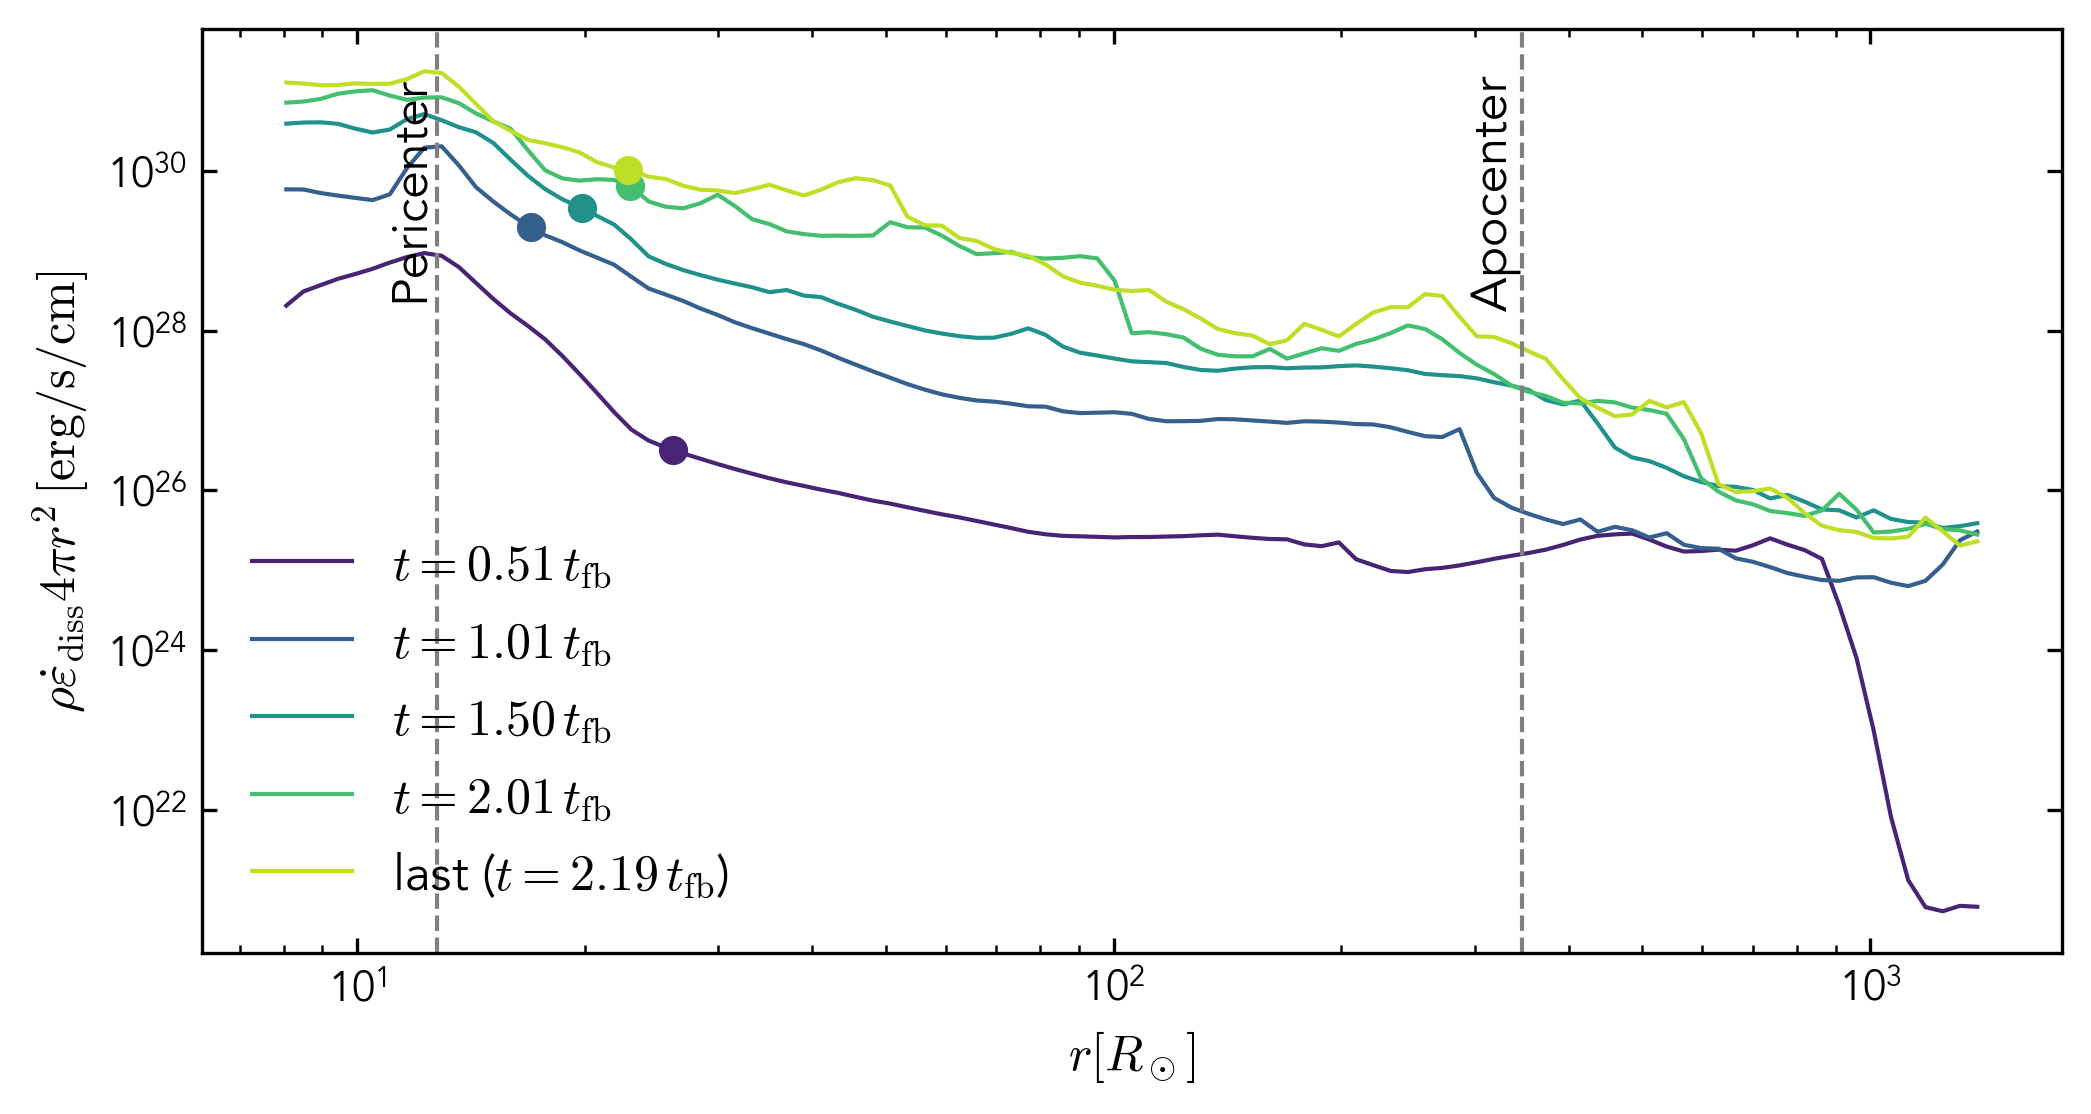

In [3]:
fig, axes = plt.subplots(figsize=(8, 4), dpi=300)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(profiles_1e4)))
for profile, color in zip(profiles_1e4, colors):
    label = (
        rf"last ($t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$)"
        if profile["is_last"]
        else rf"$t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$"
    )
    plt.plot(profile["r"], profile["dEdiss_dr"], color=color, label=label)
    plt.scatter(
        profile["Rdiss"], profile["dEdiss_dr_at_Rdiss"],
        color=color, marker='o', zorder=3,
    )

plt.axvline(tde_1e4.r_p, linestyle="--", color='gray')
plt.annotate(
    text=r"Pericenter", xy=(tde_1e4.r_p, 0.95),
    xycoords=("data", "axes fraction"), rotation=90, va="top", ha="right",
)
plt.axvline(tde_1e4.r_a, linestyle="--", color='gray')
plt.annotate(
    text=r"Apocenter", xy=(tde_1e4.r_a, 0.95),
    xycoords=("data", "axes fraction"), rotation=90, va="top", ha="right",
)
plt.yscale("log")
plt.xscale("log")
plt.ylabel(r"$\rho\dot{\varepsilon}_\mathrm{diss}4\pi r^2\,\mathrm{[erg/s/cm]}$")
plt.xlabel(r"$r[R_\odot]$")
plt.legend()
plt.show()

## 1e5

In [4]:
tde_1e5 = dev.TDEBasics(Mbh=1e5*u.Msun, Mstar=0.5*u.Msun, Rstar=0.47*u.Rsun, beta=1)
requested_tfbs_1e5 = [0.3, 0.5]
selected_1e5 = [(*SNAPSHOT_TFB("1e5", tfb), False) for tfb in requested_tfbs_1e5]
snapnums_1e5, paths_1e5 = dev.DATAPATHS("1e5")
selected_1e5.append((snapnums_1e5[-1], paths_1e5[-1], True))

profiles_1e5 = []
for snapnum, path, is_last in selected_1e5:
    snap = richio.load(path)
    time_tfb = float(np.asarray((snap.time / tde_1e5.t_fb).to_value()).squeeze())
    Ediss, r = snap.profile(
        data="dissipation", weights="volume",
        r_start=0.6 * tde_1e5.r_p, r_stop=4 * tde_1e5.r_a,
    )
    dEdiss_dr = (Ediss * 4 * np.pi * r**2).in_cgs()
    R = np.sqrt(snap.X**2 + snap.Y**2 + snap.Z**2)
    Rdiss = np.sum(snap.dissipation * snap.volume * R) / np.sum(snap.dissipation * snap.volume)
    dEdiss_dr_at_Rdiss = np.interp(
        Rdiss.to_value(r.units), r.to_value(), dEdiss_dr.to_value()
    ) * dEdiss_dr.units
    profiles_1e5.append({
        "snapnum": snapnum, "time_tfb": time_tfb, "is_last": is_last,
        "r": r, "dEdiss_dr": dEdiss_dr, "Rdiss": Rdiss,
        "dEdiss_dr_at_Rdiss": dEdiss_dr_at_Rdiss,
    })

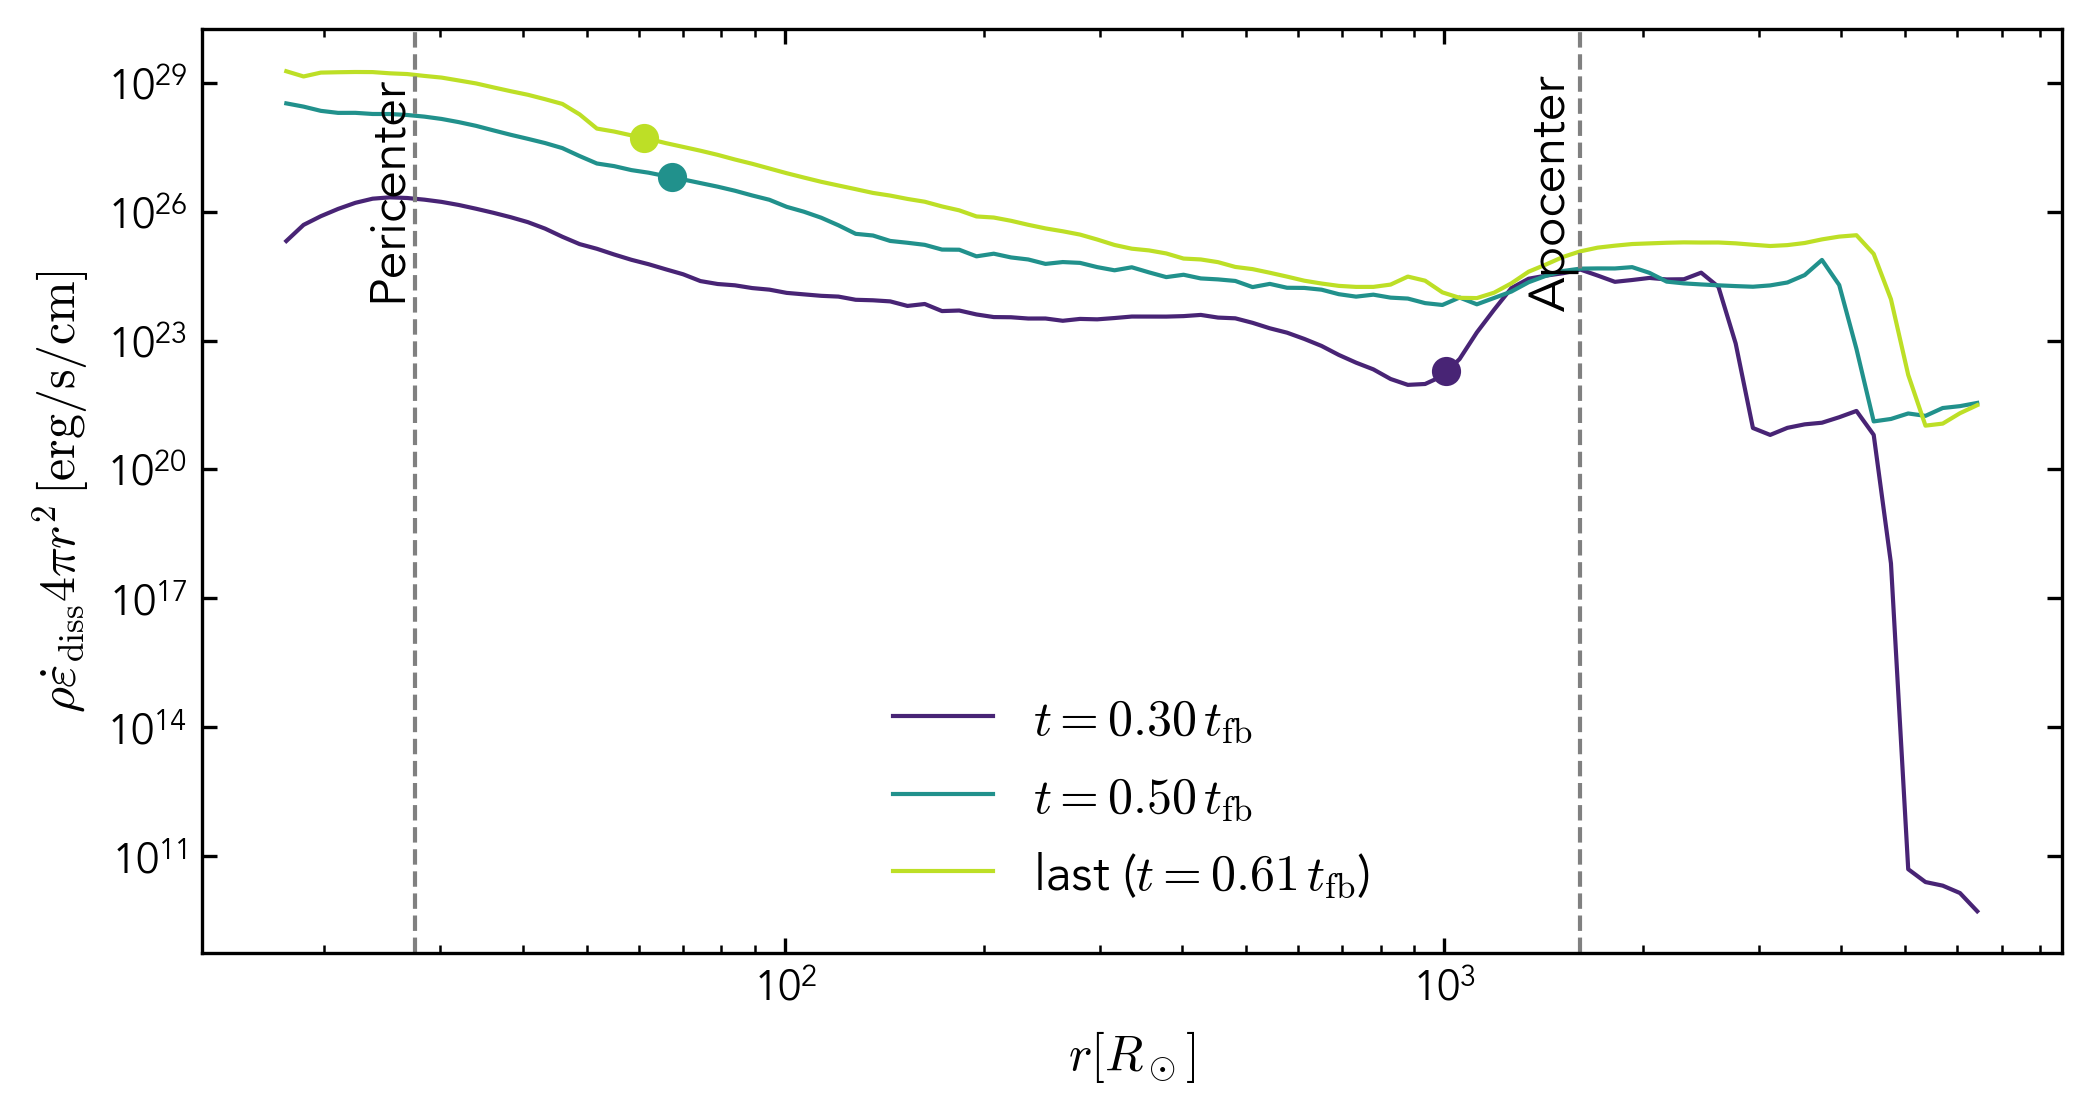

In [5]:
fig, axes = plt.subplots(figsize=(8, 4), dpi=300)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(profiles_1e5)))
for profile, color in zip(profiles_1e5, colors):
    label = (
        rf"last ($t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$)"
        if profile["is_last"]
        else rf"$t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$"
    )
    plt.plot(profile["r"], profile["dEdiss_dr"], color=color, label=label)
    plt.scatter(
        profile["Rdiss"], profile["dEdiss_dr_at_Rdiss"],
        color=color, marker='o', zorder=3,
    )

plt.axvline(tde_1e5.r_p, linestyle="--", color='gray')
plt.annotate(
    text=r"Pericenter", xy=(tde_1e5.r_p, 0.95),
    xycoords=("data", "axes fraction"), rotation=90, va="top", ha="right",
)
plt.axvline(tde_1e5.r_a, linestyle="--", color='gray')
plt.annotate(
    text=r"Apocenter", xy=(tde_1e5.r_a, 0.95),
    xycoords=("data", "axes fraction"), rotation=90, va="top", ha="right",
)
plt.yscale("log")
plt.xscale("log")
plt.ylabel(r"$\rho\dot{\varepsilon}_\mathrm{diss}4\pi r^2\,\mathrm{[erg/s/cm]}$")
plt.xlabel(r"$r[R_\odot]$")
plt.legend()
plt.show()

## 1e6

In [6]:
tde_1e6 = dev.TDEBasics(Mbh=1e6*u.Msun, Mstar=1*u.Msun, Rstar=1*u.Rsun, beta=1)
requested_tfbs_1e6 = [1.0, 1.2, 1.4, 1.5]
selected_1e6 = [(*SNAPSHOT_TFB("1e6", tfb), False) for tfb in requested_tfbs_1e6]
snapnums_1e6, paths_1e6 = dev.DATAPATHS("1e6")
selected_1e6.append((snapnums_1e6[-1], paths_1e6[-1], True))

In [ ]:
profiles_1e6 = []
for snapnum, path, is_last in selected_1e6:
    snap = richio.load(path)
    time_tfb = float(np.asarray((snap.time / tde_1e6.t_fb).to_value()).squeeze())
    Ediss, r = snap.profile(
        data="dissipation", weights="volume",
        r_start=0.6 * tde_1e6.r_p, r_stop=4 * tde_1e6.r_a,
    )
    dEdiss_dr = (Ediss * 4 * np.pi * r**2).in_cgs()
    R = np.sqrt(snap.X**2 + snap.Y**2 + snap.Z**2)
    Rdiss = np.sum(snap.dissipation * snap.volume * R) / np.sum(snap.dissipation * snap.volume)
    dEdiss_dr_at_Rdiss = np.interp(
        Rdiss.to_value(r.units), r.to_value(), dEdiss_dr.to_value()
    ) * dEdiss_dr.units
    profiles_1e6.append({
        "snapnum": snapnum, "time_tfb": time_tfb, "is_last": is_last,
        "r": r, "dEdiss_dr": dEdiss_dr, "Rdiss": Rdiss,
        "dEdiss_dr_at_Rdiss": dEdiss_dr_at_Rdiss,
    })

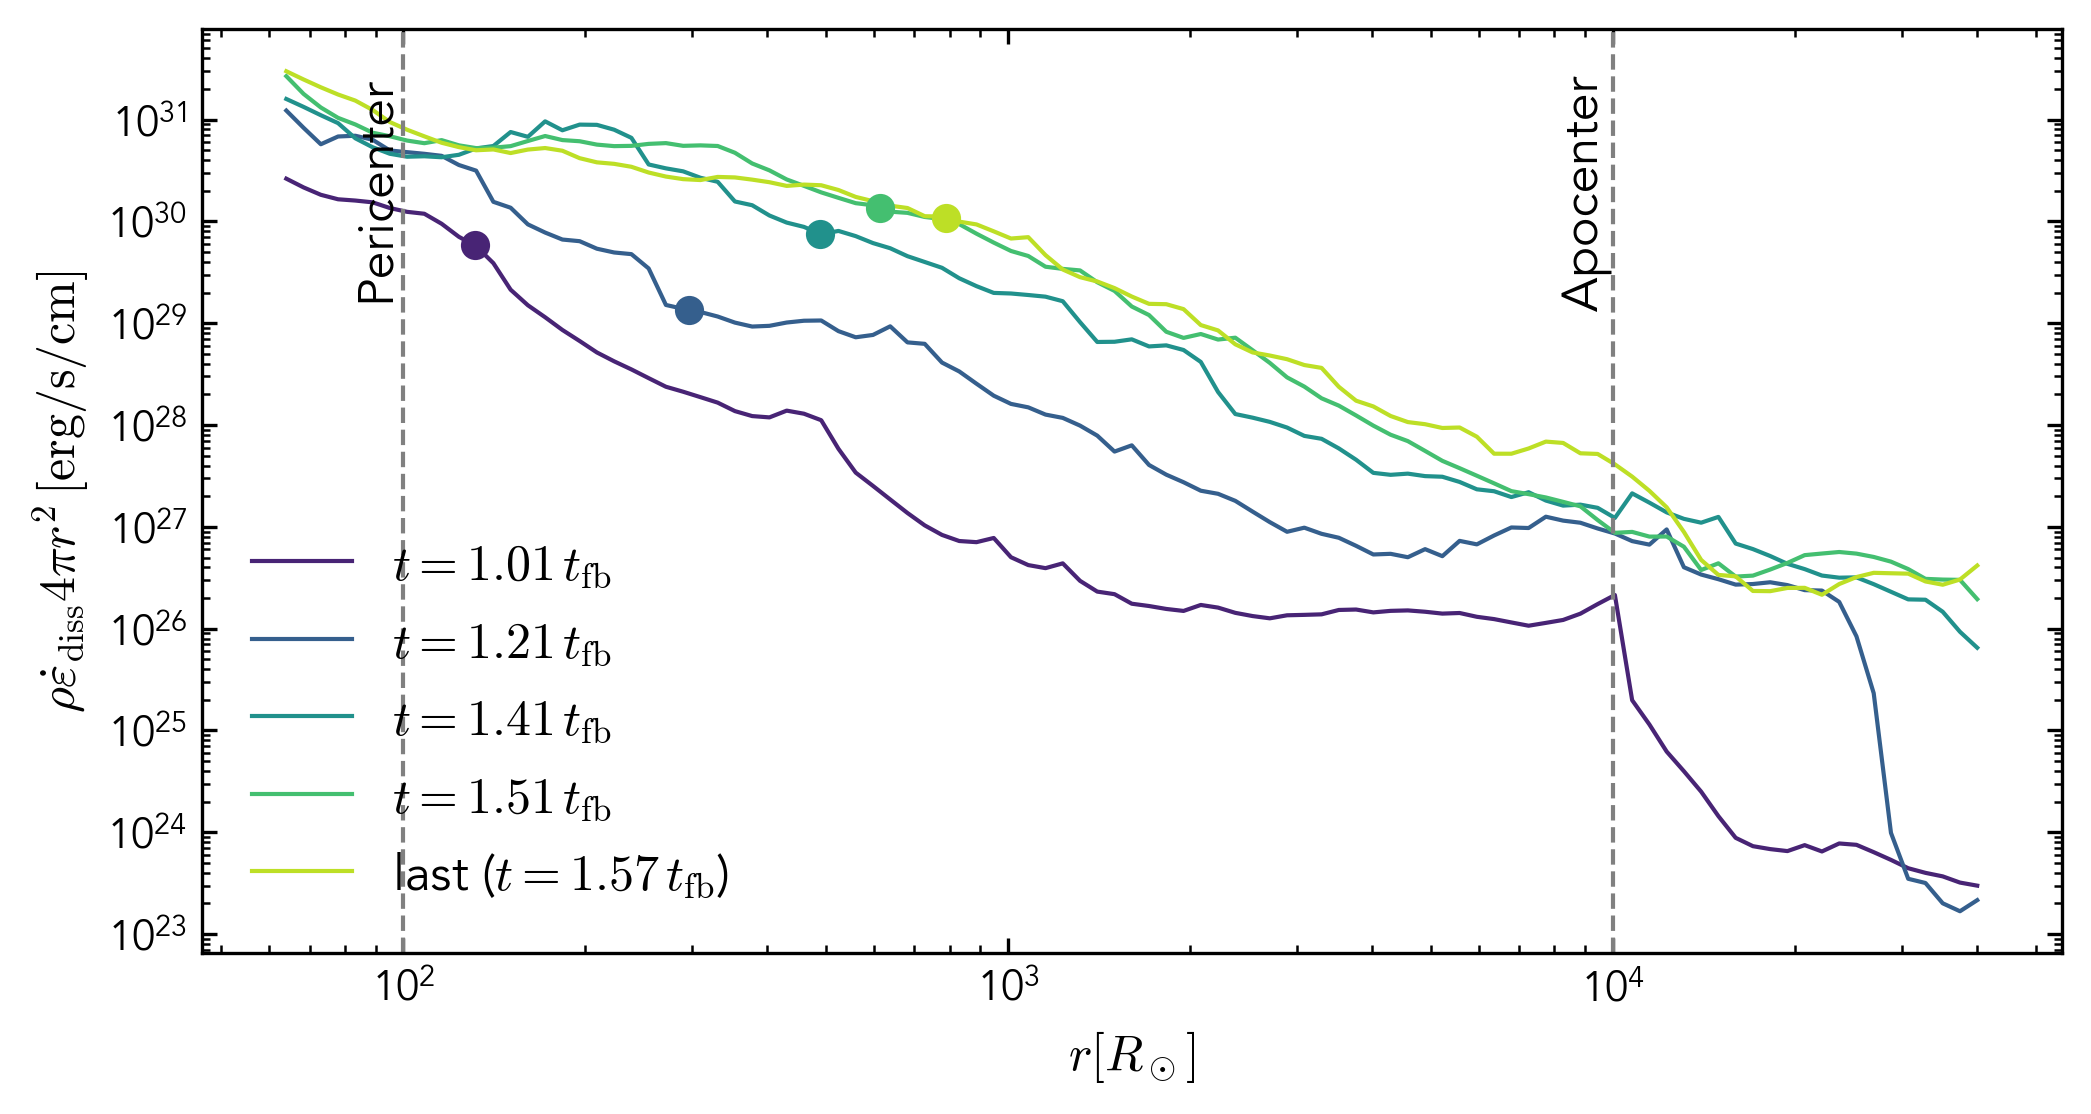

In [ ]:
fig, axes = plt.subplots(figsize=(8, 4), dpi=300)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(profiles_1e6)))
for profile, color in zip(profiles_1e6, colors):
    label = (
        rf"last ($t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$)"
        if profile["is_last"]
        else rf"$t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$"
    )
    plt.plot(profile["r"], profile["dEdiss_dr"], color=color, label=label)
    plt.scatter(
        profile["Rdiss"], profile["dEdiss_dr_at_Rdiss"],
        color=color, marker='o', zorder=3,
    )

plt.axvline(tde_1e6.r_p, linestyle="--", color='gray')
plt.annotate(
    text=r"Pericenter", xy=(tde_1e6.r_p, 0.95),
    xycoords=("data", "axes fraction"), rotation=90, va="top", ha="right",
)
plt.axvline(tde_1e6.r_a, linestyle="--", color='gray')
plt.annotate(
    text=r"Apocenter", xy=(tde_1e6.r_a, 0.95),
    xycoords=("data", "axes fraction"), rotation=90, va="top", ha="right",
)
plt.yscale("log")
plt.xscale("log")
plt.ylabel(r"$\rho\dot{\varepsilon}_\mathrm{diss}4\pi r^2\,\mathrm{[erg/s/cm]}$")
plt.xlabel(r"$r[R_\odot]$")
plt.legend()
plt.show()